# Proteome allocation model for Trichodesmium

## Parameters

In [6]:
# Maximum turnover rates for all reactions (# molecules per protein per minute)

kref = Dict(
#"exp" => 120.0,                 # C/N exporters, molecules of C and N org/min
"trn" => 120.0,                  # N transporters, atoms of N/min
"trnh4" => 120.0,                # NH4 transporters, atoms of N/min
"trdop" => 120.0,                # DOP transporters, atoms of P/min
"trpo4" => 120.0,                # PO4 transporters, atoms of P/min
#"trsFe" => 120.0,                # siderophore-bound Fe transporters, atoms of Fe/min
#"trfFe" => 120.0,                # not siderophore-bound Fe transporters, atoms of Fe/min
"din" => 2662.0,                 # DIN proteins, atoms of N/min
"ri" => 957.0,                   # ribosomes, molecules of aa/min
"lb" => 120.0,                   # lipid synthesis, atoms of C/min
"p" => 7800.0,                   # photosystems, photons/min
"ru" => 170.6,                   # rubisco, atoms of C/min
#"ld" => 120.0,                  # lipid degradation, atoms of C/min
"gl" => 120.0,                   # glycolysis, atoms of C/min
"re" => 1000.0,                  # repair proteins, atoms of C/min
"d" => 1000.0,                   # heat damage, molecules of photosystem/min
"nt" => 1061.0,                  # nitrogenase, atoms of N/min
#"sFe" => 69.2,                   # Siderophore-bound Fe(III) reduction (rate-limiting step), atoms of Fe/min
#"fFe" => 151.3,                  # Other Fe(III) reduction (rate-limiting step), atoms of Fe/min
"nh4" => 88.8,                   # NH4 (glutamate synthetase turnover rate), molecules of NH4/min
"dop" => 954.06,                 # DOP (25% phosphonate dehydrogenase, 75% AP), molecules of DOP/min
"org" => 60,                    # synthesis of organic molecules, organic molecules/min
) 

# Half-saturation constants for all reactions

K = Dict(
"exp" => 1,                      # exporters, uM C/N org molecules
"corg" => 10^4,                  # incorporation of internal carbon by synthesis of organic compounds for export, atoms of C/ um3
"norg" => 10^4,                  # incorporation of internal nitrogen by synthesis of organic compounds for export, atoms of N/ um3
"trn" => 5,                      # DIN transporters, uM DIN. This affects A LOT the range of DIN concentrations for which nitrogenase operates
"trdop" => 1.0,                  # DOP transporters, uM DOP
#"trfFe" => 1.0,                  # non siderophore-bound iron transporters, uM Fe
"ic" => 10^5,                    # incorporation of internal carbon by ribosomes, atoms of C/ um3
"in" => 10^4,                    # incorporation of internal nitrogen by ribosomes, atoms of N/ um3
"ntfe" => 10^3,                  # incorporation of internal iron by nitrogenase, atoms of Fe/ um3
"ntn" => 10^4,                   # incorporation of N2 by nitrogenase, atoms of N/um3. Assumed. Doesn't change output that much
"lb" => 10^4,                    # lipid synthesis, atoms of C/um3
"p" => 1.0,                      # photosystems, photons/um3
"pfe" => 10^2,                   # incorporation of internal iron by photosystems, atoms of Fe/um3
"ru" => 1.0,                     # rubisco, uM DIC
#"ld" => 10^4,                   # lipid degradation, atoms of C/um3
"gl" => 10^4,                    # glycolysis, atoms of C/um3
"re" => 10^4,                    # repair proteins, atoms of C/um3
"d" => 10^4,                     # heat damage, atoms of C/um3
#"sFe" => 1.0,                    # Siderophore-bound Fe(III) reduction, pM Siderophore-bound Fe
#"fFe" => 1.0,                    # Other Fe(III) reduction, pM other Fe
"nh4" => 1.0,                    # NH4 processing, uM NH4
"dop" => 1.0,                    # DOP processing, uM DOP
"trpo4" => 1.0,                  # PO4 processing, uM PO4
)

# Space and density constraints

s_trn = 1.26e-5                  # um2, specific surface area of membrane transporter molecules
Vnt = 3.7e-7                     # um3, volume / nitrogenase
s_lm = 0.5e-6                    # um2, specific surface area of membrane lipid molecules
#clm = 1.17e6                    # number of membrane lipids / um3
Mmax = 0.00045                   # unitless, maximum membrane transporter to lipid ratio
Mmin = 3e-5                      # unitless, minimum membrane transporter to lipid ratio
Vp = 3e-5                        # um3, volume / photosystem
Vli = 1.5e-9                     # um3, volume / lipid droplet
#Dmax = 270/1e15*(6.02e23)/9     # Da/um3, maximum density of the cell
Dmax = 6.14e11                   # Da/um3, maximum density of the cell
ctag_max = 2e7                   # maximum number of lipid molecules / um3 
ctag_min = 200                   # minimum number of lipid molecules / um3
β = 6                            # volume to surface area ratio of a Trichodesmium cell. Max is 40
flmp = 0.554                     # Fraction of membrane lipids that are phospholipids

# Temperature effects

Ttest = 273.0 .+ [3.0:1.0:45.0;] # K, temperature regime
Tmin = minimum(Ttest)            # K, minimum temperature
Tmax = maximum(Ttest)            # K, maximal temperature
Ea = 0.5                         # eV, activation energy  Maranon et al 2018; Barton et al 2020
Ed = 1.5                         # eV, deactivation energy
Etr  = Ea/2                      # eV, activation energy nutrient diffusion
R    = 8.62*10^-5                # eV/K, Boltzmann's constant
Tref = 20+273.0                  # K, reference temperature
Td   = 43+273.0                  # K, critical high temperature

# Molecular weights

ηaa = 110                        # Da / amino acid
ηp  = 12739*ηaa                  # Da / molecule of photosystem
ηtrn = 754*ηaa                   # Da / molecule of N transporter 
ηtrnh4 = 488*ηaa                 # Da / molecule of NH4 transporter 
#ηtrsFe = 1665*ηaa                # Da / molecule of siderophore-bound iron transporter 
#ηtrfFe = 1333*ηaa                # Da / molecule of other iron transporter 
ηdin = 1989*ηaa                  # Da / molecule of other DIN proteins
ηru = 3110*ηaa                   # Da / molecule of rubisco
ηri = 19323*ηaa                  # Da / molecule of ribosome
ηlb = 13742*ηaa                  # Da / molecule of lipid synthesis pathway proteins
ηgl = 4112*ηaa                   # Da / molecule of glycolysis pathway proteins
#ηld = 5128*ηaa                  # Da / molecule of lipid degradation pathway proteins
ηre = 6350*ηaa                   # Da / molecule of repair proteins
ηnt = 7024*ηaa                   # Da / molecule of nitrogenase
#ηsFe = 2849*ηaa                  # Da / molecule of siderophore-bound iron processing proteins
#ηfFe = 3107*ηaa                  # Da / molecule of other iron processing proteins
ηnh4 = 2515*ηaa                  # Da / molecule of NH4 processing proteins
ηdop = 728*ηaa                   # Da / molecule of DOP processing proteins
ηtrdop = 1432*ηaa                # Da / molecule of DOP transporter 
ηtrpo4 = 1272*ηaa                # Da / molecule of PO4 transporter 
ηexp = 2057*ηaa                  # Da / molecule of exporter
ηorg = 47*ηaa                    # Da / molecule of polysaccharide biosynthesis proteins
ηot = 1455391*ηaa                # Da / molecule of other proteome
ηin = 14                         # Da / nitrogen atom
ηic = 12                         # Da / carbon atom
ηip = 31                         # Da / phosphorus atom
ηife = 56                        # Da / iron atom
ηgu = 180                        # 180 Da; 6C glucose
ηli = 800                        # 800 Da; 16C TAG
cot = Dmax/4.9/110/(ηot/ηaa)     # molecules of other proteome / um3

# Carbon, Nitrogen, Iron, and Phosphorus quotas

Qpt = 0.20                       # Nitrogen to Carbon ratio of proteins
Qp  = 0.10                       # Nitrogen to Carbon ratio of photosystems
Qri = 0.33                       # Nitrogen to Carbon ratio of ribosomes
Qother = 0.20                    # Nitrogen to Carbon ratio of other proteins not simulated here
#Fpt = 0.000158*0.11              # Iron to Carbon ratio of proteins
#Fp  = 0.000158*0.33              # Iron to Carbon ratio of photosystems
#Fnt = 0.000158*0.46              # Iron to Carbon ratio of nitrogenase
ηlic = 16                        # atoms of C/ molecule of lipid
ηguc = 6                         # atoms of C/ molecule of glucose
ηaac = 5                         # atoms of C/ molecule of amino acid
ηatpp = 3                         # atoms of P/ molecule of ATP
ηrup = 2                         # atoms of P/ rubisco molecule
ηglp = 2                         # atoms of P/ glycolysis pathway proteins
#ηntaafe = 7/7024                 # atoms of Fe/aa in nitrogenase
#ηpaafe = 15/12739                # atoms of Fe/aa in photosystem
ηlip = 1/39                      # atoms of P/ atom of C in phospholipid
#atp = 6.02e5                    # molecules of ATP/um3 1-5 mM E. coli = 6.02e5-3.01e6

# Energy conversion factors

e_p  = 1.0                       # ATP / photon absorbed
e_ru = 10                        # ATP / carbon
e_trn = 1.0                      # ATP / nitrogen from DIN transported
e_trnh4 = 0.0                    # ATP / nitrogen from NH4 transported
e_trpo4 = 1.0                    # ATP / nitrogen from PO4 transported
e_trdop = 2.0                    # ATP / DOP transported
#e_sfe = 8.8                      # ATP / siderophore-bound Fe atom processed
#e_ffe = 4.6                      # ATP / other Fe atom processed
#e_trsfe = 0.0                    # ATP / siderophore-bound Fe transported
#e_trffe = 1.0                    # ATP / other Fe transported
e_ri = 3+9*5                     # ATP / amino acid
e_lb = 3.9                       # ATP / carbon
e_u  = 9e7/ctag_max              # ATP / damaged photosystem 
e_re = 4.5                       # ATP / photosystem
ep_gl = 5.0                      # ATP produced / carbon in glycolysis
ec_gl = 2.0                      # ATP consumed / carbon in glycolysis
#e_ld = 6.6                      # ATP / carbon
e_nt = 8                         # ATP / N atom fixed by nitrogenase
e_din = 5.2                      # ATP / N atom from reduced DIN not including transport
e_nh4 = 3.6                      # ATP / N atom from NH4
e_dop = 0                        # ATP / P atom from DOP
e_exp = 1                        # ATP / C and N org molecule transported

fdr = 0.4                     # fraction of respiration that happens in the dark 
td = 12*60                       # minutes, dark period (12 hours)

#cip = gs_cip
#cic = gs_cic
#cin = gs_cin
#cife = gs_cife

720

## Model

The model assumes that a cell is growing exponentially at the highest growth rate possible. For each macromolecule in the cell (c), the sum of the rates (v) of all synthesis processes minus the sum of the rates of all degradation processes is balanced by the cellular growth rate μ:

$$
\frac{dc}{dt} = \sum v_{synthesis} - \sum v_{degradation} - \mu c =0

$$

In [7]:
# Load packages
using Ipopt
using JuMP
using CSV
using DataFrames
using Plots

# Create a JuMP model, using Ipopt as the solver.
model = Model(Ipopt.Optimizer)

# Set the environment:
@NLparameter(model, T   == 20.0 + 273.0)   # K,  temperature
@NLparameter(model, DIN == 20.0)           # uM, external dissolved inorganic nitrogen
@NLparameter(model, DIC == 100.0)          # uM, external dissolved inorganic carbon
#@NLparameter(model, sfe == 200.0)          # pM, external siderophore-bound Fe
#@NLparameter(model, ffe == 0.0)            # pM, external other Fe
@NLparameter(model, NH4 == 0.0)            # uM, external NH4
@NLparameter(model, PO4 == 0.0)            # uM, external PO4 (0.06-0.54 uM SO)
@NLparameter(model, DOP == 0.5)           # uM, external DOP. 0.06 - 0.54 μM in ocean surface waters (Karl and Björkman, 2015)
@NLparameter(model, I   == 120.0)          # μmol photon m-2 s-1, irradiance

I == 120.0

In [8]:
# Define the unknown variables that we will optimize for.
@variables(model, begin
        #Growth rate
        logμ   , (start = 0.00047)       # 1/minute, log growth rate
        #Protein pools
        pdin ≥ 0, (start = gs_pdin)      # protein: number of DIN proteins without transporters / um3
        ptrn ≥ 0, (start = gs_ptrn)      # protein: number of transporters / um3
        #plb ≥ 0, (start = 1)            # protein: number of transporters / um3
        ptrnh4 ≥ 0, (start = gs_ptrnh4)  # protein: number of NH4 transporters / um3
        ptrdop ≥ 0, (start = gs_ptrdop)  # protein: number of DOP transporters / um3
        ptrpo4 ≥ 0, (start = gs_ptrpo4)  # protein: number of PO4 transporters / um3
        #psFe ≥ 0, (start = gs_psFe)      # protein: number of siderophore-bound Fe utilization proteins / um3
        #ptrsFe ≥ 0, (start = gs_ptrsFe)  # protein: number of siderophore-bound Fe transporters / um3
        #pfFe ≥ 0, (start = gs_pfFe)      # protein: number of other Fe utilization proteins / um3 
        #ptrfFe ≥ 0, (start = gs_ptrfFe)  # protein: number of other Fe transporters / um
        pnh4 ≥ 0, (start = gs_pnh4)      # protein: number of NH4 processing proteins / um3 
        pdop ≥ 0, (start = gs_pdop)      # protein: number of DOP processing proteins / um3 
        pri ≥ 0, (start = gs_pri)         # protein: number of ribosomes / um3 727.6
        pp  ≥ 0, (start = gs_pp)         # protein: number of photosystems / um3 
        pdp ≥ 0, (start = gs_pdp)        # protein: number of damaged photosystems / um3
        pru ≥ 0, (start = gs_pru)          # protein: number of rubisco / um3 
        pgl ≥ 0, (start = gs_pgl)          # protein: number of glycolysis pathway proteins / um3  
        pre ≥ 0, (start = gs_pre)        # protein: number of repair proteins / um3
        pnt ≥ 0, (start = gs_pnt)        # protein: number of nitrogenase units/ um3 
        pexp ≥ 0, (start = gs_pexp)         # protein: number of exporters/ um3 
        porg ≥ 0, (start = gs_porg)      # protein: number of proteins that synthesize organic molecules to export/ um3 
        # # Pools of other macromolecules
        cin ≥ 0, (start = gs_cin)        # other macromolecule: number of internal nitrogen atoms / um3 
        cic ≥ 0, (start = gs_cic)        # other macromolecule: number of internal carbon atoms / um3 
        #cife ≥ 0, (start = gs_cife)      # other macromolecule: number of internal iron atoms / um3 
        cip ≥ 0, (start = gs_cip)        # other macromolecule: number of internal phosphorus atoms / um3 
        ciorg ≥ 0, (start = gs_ciorg)    # other macromolecule: number of internal organic C and N molecules / um3 
        ctag≥ 0, (start = gs_ctag)       # other macromolecule: number of lipid droplets / um3 
        #Proteome allocations
        ϕtrn ≥ 0, (start = 0.002)        # relative proteome investment in: transporters (unitless)
        #ϕsFe ≥ 0, (start = 0.002)        # relative proteome investment in: siderophore-bound iron utilization proteins (unitless)
        #ϕtrsFe ≥ 0, (start = 0.002)      # relative proteome investment in: siderophore-bound iron transporters (unitless)
        #ϕfFe ≥ 0, (start = 0.002)        # relative proteome investment in: other iron utilization proteins (unitless)
        #ϕtrfFe ≥ 0, (start = 0.002)      # relative proteome investment in: other iron transporters (unitless)
        ϕdin ≥ 0, (start = 0.002)        # relative proteome investment in: DIN proteins without transporters (unitless)
        ϕnh4 ≥ 0, (start = 0.002)        # relative proteome investment in: NH4 processing proteins (unitless)
        ϕtrnh4 ≥ 0, (start = 0.002)      # relative proteome investment in: NH4 transporters (unitless)
        ϕtrpo4 ≥ 0, (start = 0.002)      # relative proteome investment in: PO4 transporters (unitless)
        ϕdop ≥ 0, (start = 0.002)        # relative proteome investment in: DOP processing proteins (unitless)
        ϕtrdop ≥ 0, (start = 0.002)      # relative proteome investment in: DOP transporters (unitless)
        ϕorg ≥ 0, (start = 0.002)        # relative proteome investment in: proteins that synthesize organic compounds to export (unitless)
        ϕri ≥ 0, (start = 0.04)          # relative proteome investment in: ribosomes (unitless)
        ϕp  ≥ 0, (start = 0.03)          # relative proteome investment in: photosystems (unitless)
        ϕru ≥ 0, (start = 0.07)         # relative proteome investment in: rubisco (unitless)
        ϕgl ≥ 0, (start = 0.15)          # relative proteome investment in: glycolysis (unitless)
        ϕre ≥ 0, (start = 0.01)          # relative proteome investment in: repair (unitless)
        ϕnt  ≥ 0, (start = 0.02)         # relative proteome investment in: nitrogenase (unitless)
        ϕexp ≥ 0, (start = 0.002)        # relative proteome investment in: exporters (unitless)
        #ϕlb ≥ 0, (start = 0.002)        # relative proteome investment in: lipid biosynthesis (unitless)
        #αlm ≥ 0, (start = 0.2)          # fraction of lipid synthesis flux used to: synthesize membrane lipids (unitless)
        #αtag≥ 0, (start = 0.6)          # fraction of lipid synthesis flux used to: synthesize lipid storage (unitless)

end)

(logμ, pdin, ptrn, ptrnh4, ptrdop, ptrpo4, pnh4, pdop, pri, pp, pdp, pru, pgl, pre, pnt, pexp, porg, cin, cic, cip, ciorg, ctag, ϕtrn, ϕdin, ϕnh4, ϕtrnh4, ϕtrpo4, ϕdop, ϕtrdop, ϕorg, ϕri, ϕp, ϕru, ϕgl, ϕre, ϕnt, ϕexp)

In [9]:
gs_pri

718.4528854994312

In [10]:
#C/N ratio should be 6.57
#C/Fe ratio should be 1/158e-6=6329.11
#C/P ratio should be 348.2
gs_cic/gs_cin
#total C should be 1.02-4.3e11`
#total N should be 1.7-7.2e10
#total Fe should be 2.62-6.79e7
#total P should be N/53
#Fe/P ratio should be 0.55

5.183914078211239

In [11]:
# Set the objective: maximize the log growth rate (logμ).
@objective(model, Max, logμ)

logμ

## General equation for reaction rates

The reaction rates catalyzed by a given protein i are represented by a Michaelis-Menten type equation:

$$

v_i = k_i p_i \frac{S_i}{S_1 + K_i}
$$

$k_i$ = turnover rate \
$p_i$ = concentration of protein \
$S_i$ = substrate concentration \
$K_i$ = half-saturation constant 


It is assumed that all enzymatic rates in the cell increase with temperature following the Arrhenius equation:

$$

k_i = k_{ref_i} \gamma _{T},

$$

where 

$$
 \gamma _{T}=exp \left[\frac{E_a}{R} \left(\frac{1}{T_{ref}}-\frac{1}{T}\right)\right]
 $$

 in which $k_{ref_i}$ is the maximum turnover rate at a reference temperature $T_{ref}$ (in kelvin), $E_a$ is the activation energy (eV), R is Boltzmann’s constant (eV $K^{−1}$), and T is the actual temperature (K).

 ## Protein synthesis flux

$$

v_{ri} = k_{ri} p_{ri} \frac{c_{ic}}{c_{ic} + K_{ic}} \frac{c_{in}}{c_{in} + K_{in}}

$$

$c_{ic}$ = pool of internal carbon \
$c_{in}$ = pool of internal nitrogen

 ## Carbon metabolism

$$
v_{ru} = k_{ru} p_{ru} \frac{DIC}{DIC + K_{ru}}
$$

The internal pool of C is given by:

$$
\frac{dc_{ic}}{dt}=v_{ru}-v_{ri}\eta_{aac} - v_{gl} -\mu c_{ic} = 0
$$

## Nitrogen metabolism

In this model, *Trichodesmium* cells can either utilize NH4, fixed N2 or DIN as N sources.

The rate of $NH_4$ utilization is given by:

$$
v_{nh4} = k_{nh4} p_{nh4} \frac{NH_4}{NH_4 + K_{nh4}}
$$

The rate of DIN transport is given by:

$$
v_{trn} = k_{trn} p_{trn} \frac{DIN}{DIN + K_{trn}}
$$

The rate of $N_2$ fixation is given by:

$$
v_{nt} = k_{nt} p_{nt} \frac{N_2}{N_2 + K_{nt}}
$$

We assume that $N_2$ is not limited, so that $N_2 >> K_{nt}$. Then,

$$
v_{nt} \approx k_{nt} p_{nt} 
$$

We also assume that $v_{trn}$ and $v_{DIN}$, the rate of nitrate and nitrite reduction, are equal (because reductases are much more efficient than transporters), such that:

$$
v_{trn} = v_{DIN} = k_{DIN} p_{DIN} 
$$

Constraint:

$$
p_{DIN} \geq \frac{v_{trn}}{k_{DIN}}
$$

The internal pool of N is given by:

$$
\frac{dC_{in}}{dt}=v_{trn}+v_{nt}+v_{nh4}-v_{ri}\eta_{aan} -\mu c_{in} = 0
$$

## Iron metabolism

*Trichodesmium* can either take siderophore-bound Fe (sFe) or other forms of iron, including organic-bound Fe, particulate-bound Fe, or free Fe (fFe). 

The uptake rate of siderophore-bound Fe is given by:

$$
v_{sFe}=k_{{sFe}}p_{{sFe}}\frac{sFe}{sFe+K_{{sFe}}}
$$

The uptake rate of other forms of iron is given by:

$$
v_{{trfFe}}=k_{{trfFe}}p_{{trfFe}}\frac{fFe}{fFe+K_{{trfFe}}}
$$

The internal pool of Fe is given by:

$$
\frac{dFe_{in}}{dt}=v_{{sFe}}+v_{{trfFe}}-v_{ri} \phi_p \eta_{paafe}-v_{ri} \phi_{nt} \eta_{ntaafe}-\mu C_{iFe} = 0,
$$

where $ v_{ri} \phi_p \eta_{paafe}$ is the Fe required to make photosystems, and $v_{ri} \phi_{nt} \eta_{ntaafe}$ is the Fe required to make nitrogenase.

We also assume that $v_{trfFe}$ and $v_{fFe}$, the rate of other Fe processing proteins, are equal (because the processing proteins are much more efficient than transporters), such that:

$$
v_{trfFe} = v_{fFe} = k_{fFe} p_{fFe} 
$$

Constraint:

$$
p_{fFe} \geq \frac{v_{trfFe}}{k_{fFe}}
$$

## Photosystems

The rate of photosystems is now dependent on the internal concentrations of Fe also:

$$
v_{{p}}=k_{{p}}p_{{p}}\frac{I}{I+K_{{p, I}}} \frac{c_{iFe}}{c_{iFe}+K_{p, Fe}}
$$

## Phosphorus metabolism

We will assume that *Trichodesmium* can either take dissolved organic phosphorus (DOP)/phosphite or phosphate/Pi. AHLs from the epibionts may enhance the uptake of DOP, as well as phosphonates.

The uptake rate of DOP is given by:

$$
v_{trDOP}=k_{{trdop}}p_{{trdop}}\frac{DOP}{DOP+K_{{trdop}}}
$$

The uptake rate of phosphate is given by:

$$
v_{{trPO_4}}=k_{{trpo4}}p_{{trpo4}}\frac{PO_4}{PO_4+K_{{trpo4}}}
$$

The internal pool of P is given by:

$$
\frac{dC_{ip}}{dt}=v_{{trDOP}}+v_{{PO_4}}-v_{lb} \cdot αlm \cdot flmp \cdot ηlip - \frac{ecost}{3} \cdot 0.001 -\mu C_{ip} = 0, 
$$

where $ {v_{lb} \cdot αlm \cdot flmp \cdot ηlip} $ is the P required to make membrane phospholipids, and $\frac{ecost}{3} \cdot 0.001$ is the P required to make ATP (very small since most ATP is recycled inside the cell).

We also assume that $v_{trDOP}$ and $v_{DOP}$, the rate of DOP processing proteins, are equal (because the processing proteins are much more efficient than transporters), such that:

$$
v_{trDOP} = v_{DOP} = k_{DOP} p_{DOP} 
$$

Constraint:

$$
p_{DOP} \geq \frac{v_{trDOP}}{k_{DOP}}
$$

#### Export of molecules

The internal pool of organic molecules to export is synthesized from the internal C and N pools, such that:

$$
v_{org}=k_{org}p_{org}\frac{c_{ic}}{c_{ic}+K_{org, C}} \frac{c_{in}}{c_{in}+K_{org, N}}
$$

The rate of export of the internal pool of organic molecules of C and N is:

$$
v_{exp}=k_{exp}p_{exp}\frac{c_{iorg}}{c_{iorg}+K_{exp}}
$$

The internal pool of organic molecules to export is given by:

$$
\frac{dC_{iorg}}{dt}=v_{{org}}-v_{{exp}}-\mu C_{iorg} = 0
$$


In [12]:
# Define any intermediate calculations.
@NLexpressions(model, begin
      #rate constants
        γTa,   exp(Ea*(1.0/(R*Tref) - 1.0/(R*T)))                                              # rate constant for enzymes; unitless
        γTd,   exp(Ed*(1.0/(R*Td) - 1.0/(R*T)))                                                # rate constant for temperature-dependent damage; unitless
        γTad,  exp(Etr*(1.0/(R*Tref) - 1.0/(R*T)))                                             # rate constant for nitrogen transport; unitless
        γTm,   (Tmax - T)/(Tmax - Tmin)                                                        # unitless
        #reaction rates 
        vp,  ( kref["p"] ) * pp * I / (K["p"] + I)                                             # photosystems reaction rate; molecules of photons/μm3/min
        vru, ( kref["ru"] * γTa ) * pru * DIC / ( K["ru"] + DIC )                              # rubisco reaction rate; atoms of carbon/μm3/min
        vtrn, ( kref["trn"] * γTad ) * ptrn * DIN/ ( K["trn"] + DIN)                           # DIN reaction rate (limited by the nitrogen transporters reaction rate); atoms of nitrogen/μm3/min
        vri, ( kref["ri"] * γTa ) * pri * (cic / ( K["ic"] + cic )) * (cin / ( K["in"] + cin)) # protein synthesis rate; molecules of amino acids/μm3/min
        #vlb, ( kref["lb"] * γTa ) * plb * cic / ( K["lb"] + cic )                             # lipid synthesis rate; atoms of carbon/μm3/min
        #vld, ( kref["ld"] * γTa ) * pld                                                       # lipid degradation rate; atoms of carbon/μm3/min
        vd,  ( kref["d"]  * γTd ) * pp * (ctag_max/ctag)                                       # heat damage rate; molecules of photosystems/μm3/min
        vre,  ( kref["re"]  * γTa ) * pre * (pdp/(pdp + pp))                                   # repair rate; molecules of photosystems/μm3/min
        #vre, ( kref["re"] * γTa ) * pre * (pdp/(pdp + K["f"]))                                # repair rate; molecules of photosystems/μm3/min; alternative approach
        #ciorg, 0.0002*cic + 0.00001*cin
        #kref_exp, DOP^2.2
        kref_exp, 120
        vexp, ( kref_exp * γTa) * pexp * (ciorg / (K["exp"] + ciorg))                       # Organic molecules export rate; C and N org molecules/μm3/min
        vorg, ( kref["org"] * γTa) * porg * (cic / ( K["corg"] + cic )) * (cin / ( K["norg"] + cin)) # Organic molecules export rate; C and N org molecules/μm3/min
        DOPt, DOP + DOP * vexp *0.01
        vgl,   ( kref["gl"] * γTa ) * pgl                                                      # glycolysis rate; atoms of carbon/μm3/min
        vnt,   ( kref["nt"] * γTa ) * pnt                                                      # N2 fixation rate; atoms of nitrogen/μm3/min                                              
        #vsFe, ( kref["sFe"] * γTa) * psFe * (sfe / (K["sFe"] + sfe))                            # siderophore-bound Fe reduction rate; atoms of Fe/μm3/min 
        #vtrfFe, ( kref["trfFe"] * γTa) * ptrfFe * (ffe / (K["trfFe"] + ffe))                           # free Fe reduction rate; atoms of Fe/μm3/min
        vnh4, ( kref["nh4"] * γTa) * pnh4 * (NH4 / (K["nh4"] + NH4))                           # NH4 processing rate; molecules of NH4/μm3/min
        vtrdop, ( kref["trdop"] * γTa) * pdop * (DOPt / (K["trdop"] + DOPt))                           # DOP processing rate; molecules of DOP/μm3/min
        vtrpo4, ( kref["trpo4"] * γTa) * ptrpo4 * (PO4 / (K["trpo4"] + PO4))                           # PO4 processing rate; molecules of PO4/μm3/min
        cgu,  vgl / ηguc * td                                                                  # storage pool for glucose to fuel dark respiration; molecules of glucose/μm3
        clm, (β - (ptrn+ ptrnh4 + ptrdop + pexp) * s_trn)/s_lm                                  # lipid membrane concentration calculated from a set β as a function of N transporters; lipid molecules/μm3 
        #cli,  vld / ηlic * td                                                                 # storage pool for lipids to fuel dark respiration; molecules of lipid storage/μm3 
        #ηaan,  ηaac * ((ϕtrn + ϕru + ϕlb + ϕld + ϕgl + ϕre + ϕnt)*Qpt + ϕri*Qri + ϕp*Qp)      # atoms of nitrogen / molecule of amino acid
        ηaan,  ηaac * ((ϕtrn + ϕru + ϕgl + ϕre + ϕnt + ϕdin + ϕnh4 + ϕdop 
        + ϕexp + ϕorg + ϕtrnh4 + ϕtrdop + ϕtrpo4)*Qpt + ϕri*Qri + ϕp*Qp)                                                     # atoms of nitrogen / molecule of amino acid
    
        vol,     4/3*π*(β*3)^3                                                                 # cell biovolume; um3
        ϵ,       1.0 - (pp + pdp) * Vp - ctag * Vli                                            # fraction of the biovolume not occupied by photosystems nor lipid storage; unitless  
        tot_p,   (pp + pdp)*ηp + pru*ηru + ptrn*ηtrn + pdin*ηdin+ + pri*ηri + pgl*ηgl +
        pre*ηre + pnh4*ηnh4 + ptrnh4*ηtrnh4 + ptrdop*ηtrdop + ptrpo4*ηtrpo4 + 
        pdop*ηdop + pnt*ηnt + pexp*ηexp + porg*ηorg + cot*ηot                                                                     # total protein content; Da/μm3
        ecost, vtrn*(e_trn+e_din) + vri*e_ri + vd*e_u + vre*e_re + vnt*e_nt + 
        vnh4*(e_nh4+e_trnh4) + vtrdop * (e_dop+e_trdop) + vtrpo4*e_trpo4 + vexp*e_exp + 
        vgl*ec_gl                                                                               # energetic demands of photosystems other than rubisco; molecules of ATP/μm3/min
        D, ηru*pru + ηri*pri + ηnt*pnt + pdin*ηdin + ηtrn*ptrn + pnh4*ηnh4 + 
        ptrnh4*ηtrnh4 + ptrdop*ηtrdop + ptrpo4*ηtrpo4 + ηgl*pgl + ηre*pre + pdop*ηdop + 
        pexp*ηexp + porg*ηorg + ηin*cin + ηic*cic + ηip*cip + cgu*ηgu + cot*ηot     

        atp, ecost*exp(logμ)
        Qn,   (ptrn*ηtrn*Qpt + pdin*ηdin*Qpt + pru*ηru*Qpt + pgl*ηgl*Qpt + pre*ηre*Qpt + 
        pri*ηri*Qri + pnt*ηnt*Qpt + pnh4*ηnh4*Qpt + ptrnh4*ηtrnh4*Qpt + ptrdop*ηtrdop*Qpt + 
        ptrpo4*ηtrpo4*Qpt + pdop*ηdop*Qpt + pexp*ηexp*Qpt + porg*ηorg*Qpt +
        (pp + pdp)*ηp*Qp + cot*ηot*Qpt)* ηaac/ηaa + cin                                                       # total number of atoms of nitrogen/um3
        Qc,   (ptrn*ηtrn + pdin*ηdin + pru*ηru + pgl*ηgl + pre*ηre + (pp + pdp)*ηp + 
        pri*ηri + pnt*ηnt + pnh4*ηnh4 + pexp*ηexp +
        porg*ηorg + pdop*ηdop + ptrnh4*ηtrnh4 + ptrdop*ηtrdop + ptrpo4*ηtrpo4 + 
        + cot*ηot)*ηaac/ηaa + cic + ctag*ηlic + cgu*ηguc                                                                    # total number of atoms of carbon/um3
        # Qf,   (ptrn*ηtrn*Fpt + pru*ηru*Fpt + pgl*ηgl*Fpt + pre*ηre*Fpt + pri*ηri*Fpt + 
        # pnt*ηnt*Fnt +ptrn*ηtrn*Fpt +psFe*ηsFe*Fpt + pfFe*ηfFe*Fpt +  pdop*ηdop*Fpt+ 
        # pexp*ηexp*Fpt + porg*ηorg*Fpt + ptrnh4*ηtrnh4*Fpt + ptrdop*ηtrdop*Fpt + 
        # ptrpo4*ηtrpo4*Fpt + ptrsFe*ηtrsFe*Fpt + ptrfFe*ηtrfFe*Qpt + (pp + pdp)*ηp*Fp + 
        # cot*ηot*Fpt)* ηaac/ηaa + cife                                                                       # total number of atoms of iron/um3
        Qp, (clm*flmp*ηlic*ηlip) + pru*ηrup + pgl*ηglp + atp*3 + cip                                               # total number of atoms of phosphorus/um3

        # Fcell, Qc/Qf                                                                           # carbon to iron quota of the cell
        Qcell, Qc/Qn                                                                           # carbon to nitrogen quota of the cell
        Pcell, Qc/Qp                                                                           # carbon to phosphorus quota of the cell
        
                                                      # concentration of all macromolecules except for photosystems, lipid storage and membrane components; Da/μm3 
end)

(subexpression[1]: exp(0.5 * (1.0 / (8.62e-5 * 293.0) - 1.0 / (8.62e-5 * T))), subexpression[2]: exp(1.5 * (1.0 / (8.62e-5 * 316.0) - 1.0 / (8.62e-5 * T))), subexpression[3]: exp(0.25 * (1.0 / (8.62e-5 * 293.0) - 1.0 / (8.62e-5 * T))), subexpression[4]: (318.0 - T) / (318.0 - 276.0), subexpression[5]: (7800.0 * pp * I) / (1.0 + I), subexpression[6]: ((170.6 * subexpression[1]) * pru * DIC) / (1.0 + DIC), subexpression[7]: ((120.0 * subexpression[3]) * ptrn * DIN) / (5.0 + DIN), subexpression[8]: (957.0 * subexpression[1]) * pri * (cic / (100000.0 + cic)) * (cin / (10000.0 + cin)), subexpression[9]: (1000.0 * subexpression[2]) * pp * (2.0e7 / ctag), subexpression[10]: (1000.0 * subexpression[1]) * pre * (pdp / (pdp + pp)), subexpression[11]: 120.0, subexpression[12]: (subexpression[11] * subexpression[1]) * pexp * (ciorg / (1.0 + ciorg)), subexpression[13]: (60.0 * subexpression[1]) * porg * (cic / (10000.0 + cic)) * (cin / (10000.0 + cin)), subexpression[14]: DOP + DOP * subexpression[

In [13]:
# Define the system of equations and constraints.
@constraints(model, begin
        ϕp + ϕru + ϕtrn + ϕdin + ϕri + ϕgl + ϕre + ϕnt + ϕnh4 + ϕdop + 
        ϕexp + ϕorg + ϕtrnh4 + ϕtrdop + ϕtrpo4 ==  0.5 #the sum of all proteome relative investments is assumed to equal 1 - ϕother
        #αlm + αtag == 1.0 #the lipids pool is comprised of the flux used to synthesize membrane lipids (αlm), those used for dark respiration (αld), and the ones that can mitigate damage (αtag) 
        #ϕld == 0
end)

(ϕtrn + ϕdin + ϕnh4 + ϕtrnh4 + ϕtrpo4 + ϕdop + ϕtrdop + ϕorg + ϕri + ϕp + ϕru + ϕgl + ϕre + ϕnt + ϕexp = 0.5,)

In [14]:
@NLconstraints(model, begin
        (ptrn + ptrnh4 + ptrdop + pexp) / 
        clm ≤ Mmin + (Mmax * γTm)                                                 # constraint on the transporter to lipid ratio in the membrane
        vtrn /kref["din"] ≤ pdin                                                  # constraint on the ratio of N transporter to DIN proteins
        vnh4 /kref["trnh4"] ≤ ptrnh4                                              # constraint on the ratio of NH4 transporter to processing proteins
        vtrdop /kref["dop"] ≤ pdop                                                # constraint on the ratio of DOP transporter to processing proteins
        # vsFe /kref["trsFe"] ≤ ptrsFe                                              # constraint on the ratio of siderophore-bound Fe transporter to processing proteins
        # vtrfFe /kref["fFe"] ≤ pfFe                                                # constraint on the ratio of other Fe transporter to processing proteins
        #β * (s_trn * ptrn + s_lm * clm) == 1.0                                   # constraint on the volume to surface area ratio of the cell
        pdp / (pdp + pp) == ( ( kref["d"]  * γTd ) * pp * 
        (ctag_max/ctag) ) / ( kref["re"] * γTa * pre )                            # damage (vd) and repair (vre) dynamics assuming vd = vre
        # Fcell ≤ 7000                                                              # constraints based on the intracellular ratios of Trichodesmium
        Pcell ≤ 500                                                               # constraints based on the intracellular ratios of Trichodesmium
        ϕp * vri * 1/(ηp/ηaa) - exp(logμ) * (pp + pdp) == 0.0                    # protein: molecules of photosystems/μm3
        # alternative approach to model folding/unfolding of photosystems:
        #ϕp * vri * 1/(ηp/ηaa) + vre - vd - exp(logμ) * pp == 0.0                  # protein: functional photosystems/μm3
        #vd - vre - exp(logμ) * pdp == 0.0                                         # protein: damaged photosystems/μm3
        ϕru * vri * 1/(ηru/ηaa) - exp(logμ) * pru == 0.0                         # protein: rubisco/μm3
        ϕtrn  * vri * 1/(ηtrn/ηaa)  - exp(logμ) * ptrn  == 0.0                    # protein: N transporters/μm3
        ϕdin  * vri * 1/(ηdin/ηaa)  - exp(logμ) * pdin  == 0.0                    # protein: DIN proteins/μm3
        ϕri * vri * 1/(ηri/ηaa) - exp(logμ) * pri == 0.0                         # protein: ribosomes/μm3
        ϕnt * vri * 1/(ηnt/ηaa) - exp(logμ) * pnt == 0.0                         # protein: nitrogenase/μm3
        #ϕlb * vri * 1/(ηlb/ηaa) - exp(logμ) * plb == 0.0                         # protein: lipid synthesis proteins/μm3
        #ϕld * vri * 1/(ηld/ηaa) - exp(logμ) * pld == 0.0                         # protein: lipid degradation proteins/μm3
        ϕgl * vri * 1/(ηgl/ηaa) - exp(logμ) * pgl == 0.0                         # protein: glycolysis proteins/μm3
        ϕre * vri * 1/(ηre/ηaa) - exp(logμ) * pre == 0.0                         # protein: repair proteinsμm3
        # ϕsFe * vri * 1/(ηsFe/ηaa) - exp(logμ) * psFe == 0.0                       # protein: siderophore-bound Fe processing proteins/μm3
        # ϕtrsFe * vri * 1/(ηtrsFe/ηaa) - exp(logμ) * ptrsFe == 0.0                 # protein: siderophore-bound Fe transporters/μm3
        # ϕfFe * vri * 1/(ηfFe/ηaa) - exp(logμ) * pfFe == 0.0                       # protein: other Fe processing proteins/μm3
        # ϕtrfFe * vri * 1/(ηtrfFe/ηaa) - exp(logμ) * ptrfFe == 0.0                 # protein: other Fe transporters/μm3
        ϕnh4 * vri * 1/(ηnh4/ηaa) - exp(logμ) * pnh4 == 0.0                       # protein: NH4 processing proteins/μm3
        ϕtrpo4 * vri * 1/(ηtrpo4/ηaa) - exp(logμ) * ptrpo4 == 0.0                 # protein: PO4 transporters/μm3
        ϕdop * vri * 1/(ηdop/ηaa) - exp(logμ) * pdop == 0.0                       # protein: DOP processing proteins/μm3
        ϕtrdop * vri * 1/(ηtrdop/ηaa) - exp(logμ) * ptrdop == 0.0                 # protein: DOP transporters/μm3
        ϕexp * vri * 1/(ηexp/ηaa) - exp(logμ) * pexp == 0.0                       # protein: exporters/μm3
        ϕorg * vri * 1/(ηorg/ηaa) - exp(logμ) * porg == 0.0                       # protein: exporters/μm3
        ϕtrnh4 * vri * 1/(ηtrnh4/ηaa) - exp(logμ) * ptrnh4 == 0.0                 # protein: NH4 transporters/μm3
        vtrn + vnt + vnh4 - vri*ηaan -vorg - exp(logμ) * cin == 0.0                # internal pool of nitrogen/μm3
        vru - vri*ηaac - vgl - vorg*3 - exp(logμ) * cic == 0.0                    # internal pool of carbon/μm3
        # vsFe + vtrfFe - vri*ϕp*ηpaafe -vri*ϕnt*ηntaafe - exp(logμ) * cife == 0.0     # internal pool of iron/μm3
        vtrpo4 + vtrdop  - vgl*ec_gl*ηatpp/ηguc - vri*ϕru*ηrup*ηaa/(ηaac*ηru) - 
        exp(logμ)*clm*flmp*ηlip - exp(logμ) * cip == 0.0   # internal pool of phosphorus/μm3
        vorg - vexp -  exp(logμ) * ciorg == 0.0                                            # internal pool of organic N and C molecules to export/μm3
        #αlm * vlb/ηlic - exp(logμ) * clm == 0.0                                  # membrane lipids/μm3 (evolved)
        #αtag * vlb/ηlic - exp(logμ) * ctag == 0.0                                # lipid storage/μm3 (used to regulate heat-damage; not used in dark respiration)
        ctag ≤ ctag_min + ctag_max                                               # constraint on the maximum concentration of ctag; lipid storage/μm3
        #vld == αld * vlb                                                         # lipid degradation rate; molecules of carbon/μm3/min
        # energetic requirements:
        vp * e_p ≥ vru * e_ru                                                    # rubisco costs are paid by photosystems; molecules of ATP/μm3/min
        ecost ≤ vp*e_p - vru*e_ru                                                # total ATP cost; molecules of ATP/μm3/min
        ecost*fdr ≤ vgl*ep_gl                                                     # dark respiration; molecules of ATP/μm3/min
        1/ϵ * D ≤ Dmax                                                           # density constraint; Da/μm3
        
end)

(((ptrn + ptrnh4 + ptrdop + pexp) / subexpression[21] - (3.0e-5 + 0.00045 * subexpression[4])) - 0.0 ≤ 0, (subexpression[7] / 2662.0 - pdin) - 0.0 ≤ 0, (subexpression[17] / 120.0 - ptrnh4) - 0.0 ≤ 0, (subexpression[18] / 954.06 - pdop) - 0.0 ≤ 0, (pdp / (pdp + pp) - ((1000.0 * subexpression[2]) * pp * (2.0e7 / ctag)) / (1000.0 * subexpression[1] * pre)) - 0.0 = 0, subexpression[33] - 500.0 ≤ 0, ((ϕp * subexpression[8] * 1.0) / (1.40129e6 / 110.0) - exp(logμ) * (pp + pdp)) - 0.0 = 0, ((ϕru * subexpression[8] * 1.0) / (342100.0 / 110.0) - exp(logμ) * pru) - 0.0 = 0, ((ϕtrn * subexpression[8] * 1.0) / (82940.0 / 110.0) - exp(logμ) * ptrn) - 0.0 = 0, ((ϕdin * subexpression[8] * 1.0) / (218790.0 / 110.0) - exp(logμ) * pdin) - 0.0 = 0, ((ϕri * subexpression[8] * 1.0) / (2.12553e6 / 110.0) - exp(logμ) * pri) - 0.0 = 0, ((ϕnt * subexpression[8] * 1.0) / (772640.0 / 110.0) - exp(logμ) * pnt) - 0.0 = 0, ((ϕgl * subexpression[8] * 1.0) / (452320.0 / 110.0) - exp(logμ) * pgl) - 0.0 = 0, ((ϕre * su

In [15]:
# Solve the optimization problem.
status = optimize!(model)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.13, running with linear solver MUMPS 5.6.1.

Number of nonzeros in equality constraint Jacobian...:      159
Number of nonzeros in inequality constraint Jacobian.:       87
Number of nonzeros in Lagrangian Hessian.............:      954

Total number of variables............................:       37
                     variables with only lower bounds:       36
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       21
Total number of inequality c

Iterate over different environmental conditions and save model output

In [16]:
# Optimal solutions looping over different environmental conditions.
env = "[DIN]" # should be one of the following: [N2] or [DIN]

if env == "[DIN]"
    # Run varying [DIN].
    change_DIN = 10.0 .^ [-7.0:0.18:log10(20.0);]
    #change_DIN = 0.0 .+ [0.0:1:20.0;]
    change_T = 20.0 + 273.0
    change_I = 120.0
elseif env == "Temperature (C°)"
    # Run varying Temperature.
    change_DIN = 20.0
    change_T  = 273.0 .+ [3.0:1.0:45.0;]
    change_I = 120.0
elseif env == "Light"
    # Run varying Light.
    change_DIN = 20.0
    change_T = 20.0 + 273.0
    change_I = 10.0 .^ [-7.0:0.18:log10(120.0);]
elseif env == "sfe"
    # Run varying Light.
    change_DIN = 20.0
    change_T = 20.0 + 273.0
    change_I = 20.0
elseif env == "ffe"
    # Run varying Light.
    change_DIN = 20.0
    change_T = 20.0 + 273.0
    change_I = 20.0
end

120.0

In [17]:
# Define empty vectors
s_μ     = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_β    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ptrn   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pdin   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pri   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_plb   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pdp   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pp    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pru   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_pld   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pgl   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pre   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pnt   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_psFe   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_pfFe   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pnh4   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ptrnh4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ptrdop  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ptrpo4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ptrsFe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ptrfFe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pdop   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_pexp   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_porg   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕtrn   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕdin   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕri   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_ϕlb   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕp    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕru   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_ϕld   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕgl   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕre   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕnt   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ϕsFe   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ϕtrsFe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ϕfFe   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ϕtrfFe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕnh4   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕtrnh4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕtrpo4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕdop   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕtrdop  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕexp   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϕorg   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_cin   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_clm   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_cic   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_cife   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_cip   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ciorg   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_Qcell = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_Fcell = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_Pcell = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_Qc    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_Qn    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_Qf    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_Qp    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vru   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vp    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vgl   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vd    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vre    = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_vlb   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_vld   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vri   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vtrn   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vol   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vnt   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_vsFe   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_vtrfFe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vnh4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vtrpo4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vtrdop  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vexp  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_vorg  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_totp  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_αld   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_D     = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_γTa   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_γTd   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_γTad  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_γTm   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
#s_cli   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_cgu   = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ecost = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ηaan  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ϵ     = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_ctag = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_αlm  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_αtag  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_T  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_DIN  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_I  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_sfe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
# s_ffe  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_nh4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_po4  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))
s_dop  = Array{Float64,3}(undef,length(change_T),length(change_DIN),length(change_I))

1×47×1 Array{Float64, 3}:
[:, :, 1] =
 2.47402e-314  2.47402e-314  2.47402e-314  …  5.0e-324  2.50915e-314

In [18]:
# Store model output in empty vectors
for i in 1:length(change_DIN)
    set_value(DIN, change_DIN[i])
    for j in 1:length(change_T)
            set_value(T, change_T[j])
            for k in 1:length(change_I)
                    set_value(I, change_I[k])
                    optimize!(model)
                        s_μ[j,i,k]   = exp.(JuMP.value.(logμ))
                        #s_β[j,i,k]   = JuMP.value.(β)
                        s_ptrn[j,i,k] = JuMP.value.(ptrn)
                        s_pdin[j,i,k] = JuMP.value.(pdin)
                        s_pri[j,i,k] = JuMP.value.(pri)
                        #s_plb[j,i,k] = JuMP.value.(plb)
                        s_pdp[j,i,k] = JuMP.value.(pdp)
                        s_pp[j,i,k]  = JuMP.value.(pp)
                        s_pru[j,i,k] = JuMP.value.(pru)
                        #s_pld[j,i,k] = JuMP.value.(pld)
                        s_pgl[j,i,k] = JuMP.value.(pgl)
                        s_pre[j,i,k] = JuMP.value.(pre)
                        s_pnt[j,i,k] = JuMP.value.(pnt)
                        #s_psFe[j,i,k] = JuMP.value.(psFe)
                        # s_pfFe[j,i,k] = JuMP.value.(pfFe)
                        s_pnh4[j,i,k] = JuMP.value.(pnh4)
                        s_ptrnh4[j,i,k] = JuMP.value.(ptrnh4)
                        s_ptrdop[j,i,k] = JuMP.value.(ptrdop)
                        s_ptrpo4[j,i,k] = JuMP.value.(ptrpo4)
                        # s_ptrsFe[j,i,k] = JuMP.value.(ptrsFe)
                        # s_ptrfFe[j,i,k] = JuMP.value.(ptrfFe)
                        s_pdop[j,i,k] = JuMP.value.(pdop)
                        s_pexp[j,i,k] = JuMP.value.(pexp)
                        s_porg[j,i,k] = JuMP.value.(porg)
                        s_ϕtrn[j,i,k] = JuMP.value.(ϕtrn)
                        s_ϕdin[j,i,k] = JuMP.value.(ϕdin)
                        s_ϕri[j,i,k] = JuMP.value.(ϕri)
                        #s_ϕlb[j,i,k] = JuMP.value.(ϕlb)
                        s_ϕp[j,i,k]  = JuMP.value.(ϕp)
                        s_ϕru[j,i,k] = JuMP.value.(ϕru)
                        #s_ϕld[j,i,k] = JuMP.value.(ϕld)
                        s_ϕgl[j,i,k] = JuMP.value.(ϕgl)
                        s_ϕre[j,i,k] = JuMP.value.(ϕre)
                        s_ϕnt[j,i,k] = JuMP.value.(ϕnt)
                        # s_ϕsFe[j,i,k] = JuMP.value.(ϕsFe)
                        # s_ϕtrsFe[j,i,k] = JuMP.value.(ϕtrsFe)
                        # s_ϕfFe[j,i,k] = JuMP.value.(ϕfFe)
                        # s_ϕtrfFe[j,i,k] = JuMP.value.(ϕtrfFe)
                        s_ϕnh4[j,i,k] = JuMP.value.(ϕnh4)
                        s_ϕtrnh4[j,i,k] = JuMP.value.(ϕtrnh4)
                        s_ϕtrdop[j,i,k] = JuMP.value.(ϕtrdop)
                        s_ϕtrpo4[j,i,k] = JuMP.value.(ϕtrpo4)
                        s_ϕdop[j,i,k] = JuMP.value.(ϕdop)
                        s_ϕexp[j,i,k] = JuMP.value.(ϕexp)
                        s_ϕorg[j,i,k] = JuMP.value.(ϕorg)
                        s_cin[j,i,k] = JuMP.value.(cin)
                        s_clm[j,i,k] = value(clm)
                        s_cic[j,i,k]  = JuMP.value.(cic)
                        # s_cife[j,i,k]  = JuMP.value.(cife)
                        s_cip[j,i,k]  = JuMP.value.(cip)
                        s_ciorg[j,i,k]  = value(ciorg)
                        s_Qcell[j,i,k] = value(Qcell)
                        # s_Fcell[j,i,k] = value(Fcell)
                        s_Pcell[j,i,k] = value(Pcell)
                        s_Qc[j,i,k] = value(Qc)
                        s_Qn[j,i,k] = value(Qn)
                        # s_Qf[j,i,k] = value(Qf)
                        s_Qp[j,i,k] = value(Qp)
                        s_vru[j,i,k]  = value(vru)
                        s_vp[j,i,k]   = value(vp)
                        s_vgl[j,i,k]  = value(vgl)
                        s_vd[j,i,k]   = value(vd)
                        s_vre[j,i,k]   = value(vre)
                        #s_vlb[j,i,k]  = value(vlb)
                        #s_vld[j,i,k]  = value(vld)
                        s_vri[j,i,k]  = value(vri)
                        s_vtrn[j,i,k]  = value(vtrn)
                        s_vol[j,i,k]  = value(vol)
                        s_vnt[j,i,k]  = value(vnt)
                        # s_vsFe[j,i,k]  = value(vsFe)
                        # s_vtrfFe[j,i,k]  = value(vtrfFe)
                        s_vnh4[j,i,k]  = value(vnh4)
                        s_vtrpo4[j,i,k]  = value(vtrpo4)
                        s_vtrdop[j,i,k]  = value(vtrdop)
                        s_vexp[j,i,k]  = value(vexp)
                        s_vorg[j,i,k]  = value(vorg)
                        s_totp[j,i,k] = value(tot_p)
                        #s_αld[j,i,k]  = JuMP.value.(αld)
                        s_D[j,i,k]    = value(D)
                        s_γTa[j,i,k]  = value(γTa)
                        s_γTd[j,i,k]  = value(γTd)
                        s_γTad[j,i,k] = value(γTad)
                        s_γTm[j,i,k]  = value(γTm)
                        #s_cli[j,i,k]  = value(cli)
                        s_cgu[j,i,k]  = value(cgu)
                        s_ecost[j,i,k] = value(ecost)
                        s_ηaan[j,i,k]  = value(ηaan)
                        s_ϵ[j,i,k]     = value(ϵ)
                        s_ctag[j,i,k]  = JuMP.value.(ctag)
                        #s_αlm[j,i,k]  = JuMP.value.(αlm)
                        #s_αtag[j,i,k]  = JuMP.value.(αtag)
                        s_T[j,i,k] = value(T)
                        s_DIN[j,i,k] = value(DIN)
                        s_I[j,i,k] = value(I)
                        # s_sfe[j,i,k] = value(sfe)
                        # s_ffe[j,i,k] = value(ffe)
                        s_nh4[j,i,k] = value(NH4)
                        s_po4[j,i,k] = value(PO4)
                        s_dop[j,i,k] = value(DOPt)
            end
    end
end

This is Ipopt version 3.14.13, running with linear solver MUMPS 5.6.1.

Number of nonzeros in equality constraint Jacobian...:      159
Number of nonzeros in inequality constraint Jacobian.:       87
Number of nonzeros in Lagrangian Hessian.............:      954

Total number of variables............................:       37
                     variables with only lower bounds:       36
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       21
Total number of inequality constraints...............:       10
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        9

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.7000000e-04 2.13e+07 1.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [19]:
#Store good solutions

# gs_pdin = s_pdin[1,39,1,1,1]
# gs_ptrn = s_ptrn[1,39,1,1,1]
# gs_ptrnh4 = s_ptrnh4[1,39,1,1,1]
# gs_ptrdop = s_ptrdop[1,39,1,1,1]
# gs_ptrpo4 = s_ptrpo4[1,39,1,1,1]
# gs_pnh4 = s_pnh4[1,39,1,1,1]
# gs_pdop = s_pdop[1,39,1,1,1]
# gs_pri = s_pri[1,39,1,1,1]
# gs_pp = s_pp[1,39,1,1,1]             
# gs_pdp = s_pdp[1,39,1,1,1]                           
# gs_pru = s_pru[1,39,1,1,1]
# gs_pgl = s_pgl[1,39,1,1,1]
# gs_pre = s_pre[1,39,1,1,1]                              
# gs_pnt = s_pnt[1,39,1,1,1]
# gs_pexp = s_pexp[1,39,1,1,1]
# gs_porg = s_porg[1,39,1,1,1]
# gs_cin = s_cin[1,39,1,1,1]
# gs_cic = s_cic[1,39,1,1,1]
# gs_cip = s_cip[1,39,1,1,1]
# gs_ciorg = s_ciorg[1,39,1,1,1]
# gs_ctag = s_ctag[1,39,1,1,1]
# gs_ϕtrn = s_ϕtrn[1,39,1,1,1]
# gs_ϕdin = s_ϕdin[1,39,1,1,1]
# gs_ϕnh4 = s_ϕnh4[1,39,1,1,1]
# gs_ϕtrnh4 = s_ϕtrnh4[1,39,1,1,1]
# gs_ϕtrpo4 = s_ϕtrpo4[1,39,1,1,1]
# gs_ϕdop = s_ϕdop[1,39,1,1,1]
# gs_ϕtrdop = s_ϕtrdop[1,39,1,1,1]
# gs_ϕorg = s_ϕorg[1,39,1,1,1]
# gs_ϕri = s_ϕri[1,39,1,1,1]
# gs_ϕp = s_ϕp[1,39,1,1,1]
# gs_ϕru = s_ϕru[1,39,1,1,1]
# gs_ϕgl = s_ϕgl[1,39,1,1,1]
# gs_ϕre = s_ϕre[1,39,1,1,1]
# gs_ϕnt = s_ϕnt[1,39,1,1,1]
# gs_ϕexp = s_ϕexp[1,39,1,1,1]

#Start by running the code with these params
# gs_pdin = 0.001630586187886239
# gs_ptrn = 0.005437913772077567
# gs_ptrnh4 = 0.006584685272658271
# gs_ptrdop = 0.001137184368828125
# gs_ptrpo4 = 0.0012803436720001447
# gs_psFe = 6.94659616043402
# gs_ptrsFe = 3.9862571716613298
# gs_pfFe = 0.00035388405355112767
# gs_ptrfFe = 0.000413208519128898
# gs_pnh4 = 0.0006475488381151023
# gs_pdop = 37644.38245808841
# gs_pri = 718.4528854994312
# gs_pp = 16933.619276178302     
# gs_pdp = 1395.227459654503                
# gs_pru = 45619.53721272973
# gs_pgl = 35956.1828641743
# gs_pre = 2950.5437209784054                   
# gs_pnt = 264.4082902075926
# gs_pexp = 37.11183275760849
# gs_porg = 74.71363163384362
# gs_cin = 1.5307065848758505e6
# gs_cic = 7.935051414948568e6
# gs_cife = 552288.3977227879
# gs_cip = 2.1128869844281856e7
# gs_ciorg = 773.5834444492903
# gs_ctag = 2.000019933757038e7


 #s_vnt[1,35,1,1,1]

In [20]:
gs_pdin, gs_ptrn,gs_ptrnh4, gs_ptrdop, gs_ptrpo4, gs_psFe, gs_ptrsFe, gs_pfFe, gs_ptrfFe, gs_pnh4, gs_pdop, 
gs_pri, gs_pp, gs_pdp, gs_pru, gs_pgl, gs_pre, gs_pnt, gs_pexp, gs_porg, gs_cin, gs_cic, gs_cife, gs_cip, gs_ciorg, gs_ctag

(0.001630586187886239, 0.005437913772077567, 0.006584685272658271, 0.001137184368828125, 0.0012803436720001447, 6.94659616043402, 3.9862571716613298, 0.00035388405355112767, 0.000413208519128898, 0.0006475488381151023, 37644.38245808841, 718.4528854994312, 16933.619276178302, 1395.227459654503, 45619.53721272973, 35956.1828641743, 2950.5437209784054, 264.4082902075926, 37.11183275760849, 74.71363163384362, 1.5307065848758505e6, 7.935051414948568e6, 552288.3977227879, 2.1128869844281856e7, 773.5834444492903, 2.000019933757038e7)

In [21]:
using CSV
using DataFrames

a = length(change_T)
b = length(change_DIN)
c = length(change_I)

1

In [22]:
# Reshape the array into a 1-dimensional array
temp = reshape(s_T .- 273.0, (a * b *c, 1))
mu = reshape(s_μ *60*24, (a * b *c, 1))
#size = reshape(s_β*3*2, (a * b *c, 1))
phot = reshape(s_vru, (a * b *c, 1))
totp = reshape(s_totp, (a * b *c, 1))
chlvol = reshape(s_pp + s_pdp, (a * b *c, 1))
#ilpd = reshape(s_ϕld, (a * b *c, 1))
icbd = reshape(s_ϕgl, (a * b *c, 1))
ichl = reshape(s_ϕp, (a * b *c, 1))
icha = reshape(s_ϕre, (a * b *c, 1))
itrn = reshape(s_ϕtrn, (a * b *c, 1)) #nitrogen transporter proteome
idin = reshape(s_ϕdin, (a * b *c, 1)) #DIN proteome
#ilpb = reshape(s_ϕlb, (a * b *c, 1))
irib = reshape(s_ϕri, (a * b *c, 1))
irub = reshape(s_ϕru, (a * b *c, 1))
init = reshape(s_ϕnt, (a * b *c, 1)) #added for nitrogenase proteome
# isfe = reshape(s_ϕsFe, (a * b *c, 1)) #added for siderophore-bound Fe proteome
# iffe = reshape(s_ϕfFe, (a * b *c, 1)) #added for other Fe proteome
inh4 = reshape(s_ϕnh4, (a * b *c, 1)) #added for NH4 proteome
itrnh4 = reshape(s_ϕtrnh4, (a * b *c, 1)) #added for NH4 transporter proteome
itrdop = reshape(s_ϕtrdop, (a * b *c, 1)) #added for DOP transporter proteome
itrpo4 = reshape(s_ϕtrpo4, (a * b *c, 1)) #added for PO4 transporter proteome
# itrsfe = reshape(s_ϕtrsFe, (a * b *c, 1)) #added for siderophore-bound Fe transporter proteome
# itrffe = reshape(s_ϕtrsFe, (a * b *c, 1)) #added for other Fe transporter proteome
idop = reshape(s_ϕdop, (a * b *c, 1)) #added for DOP proteome
iexp = reshape(s_ϕexp, (a * b *c, 1)) #added for export proteome
iorg = reshape(s_ϕorg, (a * b *c, 1)) #added for organic molecules synthesis proteome
clip = reshape(s_clm, (a * b *c, 1))
ctrn = reshape(s_ptrn, (a * b *c, 1)) # protein: number of nitrogen transporters / um3
cdin = reshape(s_pdin, (a * b *c, 1)) # protein: number of DIN proteins / um3
cp = reshape(s_pp, (a * b *c, 1))
cup = reshape(s_pdp, (a * b *c, 1))
cri = reshape(s_pri, (a * b *c, 1))
cnt = reshape(s_pnt, (a * b *c, 1)) # protein: number of nitrogenase / um3
# csfe = reshape(s_psFe, (a * b *c, 1)) # protein: number of siderophore-bound Fe processing proteins / um3
# cffe = reshape(s_pfFe, (a * b *c, 1)) # protein: number of other Fe processing proteins / um3
cnh4 = reshape(s_pnh4, (a * b *c, 1)) # protein: number of NH4 processing proteins / um3
ctrnh4 = reshape(s_ptrnh4, (a * b *c, 1)) # protein: number of NH4 transporters / um3
ctrdop = reshape(s_ptrdop, (a * b *c, 1)) # protein: number of DOP transporters / um3
ctrpo4 = reshape(s_ptrpo4, (a * b *c, 1)) # protein: number of PO4 transporters / um3
# ctrsFe = reshape(s_ptrsFe, (a * b *c, 1)) # protein: number of siderophore-bound Fe transporters / um3
# ctrfFe = reshape(s_ptrfFe, (a * b *c, 1)) # protein: number of other Fe transporters / um3
cdop = reshape(s_pdop, (a * b *c, 1)) # protein: number of DOP processing proteins / um3
cexp = reshape(s_pexp, (a * b *c, 1)) # protein: number of exporter proteins / um3
corg = reshape(s_porg, (a * b *c, 1)) # protein: number of proteins for synthesis of organic molecules / um3
#cli = reshape(s_cli, (a * b *c, 1))
cgu = reshape(s_cgu, (a * b *c, 1))
ctag = reshape(s_ctag, (a * b *c, 1))
#ctot = reshape(s_cli * ηlic .+ s_cgu * ηguc .+ s_ctag * ηlic, (a * b * c, 1))
vtrn = reshape(s_vtrn, (a * b *c, 1)) # nitrogen transporters reaction rate; atoms of nitrogen/μm3/min
vnt = reshape(s_vnt, (a * b *c, 1)) # N2 fixation reaction rate; atoms of nitrogen/μm3/min
# vsFe = reshape(s_vsFe, (a * b *c, 1)) # siderophore-bound Fe processing rate; atoms of Fe/μm3/min
# vtrfFe = reshape(s_vtrfFe, (a * b *c, 1)) # other Fe processing rate; atoms of Fe/μm3/min
vnh4 = reshape(s_vnh4, (a * b *c, 1)) # NH4 processing rate; molecules of NH4/μm3/min
vtrpo4 = reshape(s_vtrpo4, (a * b *c, 1)) # PO4 processing rate; molecules of PO4/μm3/min
vtrdop = reshape(s_vtrdop, (a * b *c, 1)) # DOP processing rate; molecules of DOP/μm3/min
vexp = reshape(s_vexp, (a * b *c, 1)) # Exporter rate; organic C and N molecules /μm3/min
vorg = reshape(s_vorg, (a * b *c, 1)) # Rate of synthesis of organic molecules; organic C and N molecules /μm3/min
ecost = reshape(s_ecost, (a * b *c, 1))
Qcell = reshape(s_Qcell, (a * b *c, 1))
# Fcell = reshape(s_Fcell, (a * b *c, 1))
Pcell = reshape(s_Pcell, (a * b *c, 1))
# Qf = reshape(s_Qf, (a * b *c, 1))
Qc = reshape(s_Qc, (a * b *c, 1))
Qn = reshape(s_Qn, (a * b *c, 1))
# Qf = reshape(s_Qf, (a * b *c, 1))# total number of atoms of iron/um3
Qp = reshape(s_Qp, (a * b *c, 1))# total number of atoms of phosphorus/um3
cic = reshape(s_cic, (a * b *c, 1))
cin = reshape(s_cin, (a * b *c, 1))
# cife = reshape(s_cife, (a * b *c, 1)) #Internal iron atoms / um3
cip = reshape(s_cip, (a * b *c, 1)) #Internal phosphorus atoms / um3
ciorg = reshape(s_ciorg, (a * b *c, 1)) #Internal organic C and N molecules for export / um3
naan= reshape(s_ηaan, (a * b *c, 1))
vgl = reshape(s_vgl, (a * b *c, 1))
vp = reshape(s_vp, (a * b *c, 1))
vre = reshape(s_vre, (a * b *c, 1))
vri = reshape(s_vri, (a * b *c, 1))
din = reshape(s_DIN, (a * b *c, 1))
light = reshape(s_I, (a * b *c, 1))
# sfe = reshape(s_sfe, (a * b *c, 1))
# ffe = reshape(s_ffe, (a * b *c, 1))
nh4 = reshape(s_nh4, (a * b *c, 1))
po4 = reshape(s_po4, (a * b *c, 1))
dop = reshape(s_dop, (a * b *c, 1))

47×1 Matrix{Float64}:
 22.73835247633108
 22.73835247633107
 22.73835247633108
 22.738352476331094
 22.73835247633095
 22.738352476331006
 22.738352476331073
 22.738352476330956
 22.738352476331006
 22.73835247633107
  ⋮
 22.738352461716932
 22.738352425687822
 22.70103850438289
 15.6672033325417
 18.044466290857667
 20.280401236493667
 22.257334006355414
 23.60549467803847
 23.647972113269585

In [23]:
output =  DataFrame(
    "temp" => temp[:], 
    "mu" => mu[:], 
    #"size" => size[:], 
    "phot" => phot[:], 
    "totp" => totp[:], 
    "chlvol" => chlvol[:], 
    "icbd" => icbd[:], 
    "ichl" => ichl[:], 
    "icha" => icha[:], 
    "itrn" => itrn[:],
    "idin" => idin[:],
    "irib" => irib[:], 
    "irub" => irub[:], 
    "init" => init[:],
    # "isfe" => isfe[:],
    # "iffe" => iffe[:], 
    "inh4" => inh4[:],
    "itrnh4" => itrnh4[:],
    "itrdop" => itrdop[:],
    "itrpo4" => itrpo4[:],
    # "itrsfe" => itrsfe[:],
    # "itrffe" => itrffe[:],
    "idop" => idop[:], 
    "iexp" => iexp[:], 
    "iorg" => iorg[:],
    #"ilpb" => ilpb[:],
    "clip" => clip[:], 
    "ctrn" => ctrn[:], 
    "cdin" => cdin[:], 
    "cp" => cp[:], 
    "cup" => cup[:], 
    "cri" => cri[:], 
    "cnt" => cnt[:],
    # "csfe" => csfe[:],
    # "cffe" => cffe[:], 
    "cnh4" => cnh4[:], 
    "ctrnh4" => ctrnh4[:],
    "ctrdop" => ctrdop[:], 
    "ctrpo4" => ctrpo4[:],
    # "ctrsFe" => ctrsFe[:],
    # "ctrfFe" => ctrfFe[:],
    "cdop" => cdop[:],  
    "cexp" => cexp[:],
    "corg" => corg[:],  
    "cgu" => cgu[:], 
    "ctag" => ctag[:], 
    "vtrn" => vtrn[:], 
    "vnt" => vnt[:], 
    # "vsFe" => vsFe[:],
    # "vtrfFe" => vtrfFe[:], 
    "vnh4" => vnh4[:],
    "vtrpo4" => vtrpo4[:],
    "vtrdop" => vtrdop[:],
    "vexp" => vexp[:],
    "vorg" => vorg[:],
    "ecost" => ecost[:],
    "Qcell" => Qcell[:], 
    # "Fcell" => Fcell[:], 
    "Pcell" => Pcell[:],
    "Qc" => Qc[:], 
    "Qn" => Qn[:], 
    # "Qf" => Qf[:],
    "Qp" => Qp[:],
    "cic" => cic[:], 
    "cin" => cin[:],
    # "cife" => cife[:], 
    "cip" => cip[:],
    "ciorg" => ciorg[:],
    "naan" => naan[:], 
    "vgl" => vgl[:],
    "vp" => vp[:], 
    "vre" => vre[:],
    "vri" => vri[:],
    "DIN" => din[:], 
    "light" => light[:],
    # "sfe" => sfe[:], 
    # "ffe" => ffe[:],
    "nh4" => nh4[:],
    "po4" => po4[:],
    "dop" => dop[:],
    )

Row,temp,mu,phot,totp,chlvol,icbd,ichl,icha,itrn,idin,irib,irub,init,inh4,itrnh4,itrdop,itrpo4,idop,iexp,iorg,clip,ctrn,cdin,cp,cup,cri,cnt,cnh4,ctrnh4,ctrdop,ctrpo4,cdop,cexp,corg,cgu,ctag,vtrn,vnt,vnh4,vtrpo4,vtrdop,vexp,vorg,ecost,Qcell,Pcell,Qc,Qn,Qp,cic,cin,cip,ciorg,naan,vgl,vp,vre,vri,DIN,light,nh4,po4,dop
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0.000647549,0.00658469,0.00113718,0.00128034,37644.4,37.1118,74.7136,5.17769e8,2.00002e7,5.18299e-9,2.80537e5,0.0,0.0,4.32703e6,4447.67,4448.12,5.39343e7,7.45066,499.998,1.20562e10,1.61814e9,2.41125e7,7.93505e6,1.53071e6,2.11289e7,773.583,0.407958,4.31474e6,1.30991e8,2.24601e5,6.74595e5,1.0e-7,120.0,0.0,0.0,22.7384
2,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0.000647549,0.00658469,0.00113718,0.00128034,37644.4,37.1118,74.7136,5.17769e8,2.00002e7,7.84477e-9,2.80537e5,0.0,0.0,4.32703e6,4447.67,4448.12,5.39343e7,7.45066,499.998,1.20562e10,1.61814e9,2.41125e7,7.93505e6,1.53071e6,2.11289e7,773.583,0.407958,4.31474e6,1.30991e8,2.24601e5,6.74595e5,1.51356e-7,120.0,0.0,0.0,22.7384
3,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0.000647549,0.00658469,0.00113718,0.00128034,37644.4,37.1118,74.7136,5.17769e8,2.00002e7,1.18735e-8,2.80537e5,0.0,0.0,4.32703e6,4447.67,4448.12,5.39343e7,7.45066,499.998,1.20562e10,1.61814e9,2.41125e7,7.93505e6,1.53071e6,2.11289e7,773.583,0.407958,4.31474e6,1.30991e8,2.24601e5,6.74595e5,2.29087e-7,120.0,0.0,0.0,22.7384
4,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0.000647549,0.00658469,0.00113718,0.00128034,37644.4,37.1118,74.7136,5.17769e8,2.00002e7,1.79713e-8,2.80537e5,0.0,0.0,4.32703e6,4447.67,4448.12,5.39343e7,7.45066,499.998,1.20562e10,1.61814e9,2.41125e7,7.93505e6,1.53071e6,2.11289e7,773.583,0.407958,4.31474e6,1.30991e8,2.24601e5,6.74595e5,3.46737e-7,120.0,0.0,0.0,22.7384
5,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0.000647549,0.00658469,0.00113718,0.00128034,37644.4,37.1118,74.7136,5.17769e8,2.00002e7,2.72007e-8,2.80537e5,0.0,0.0,4.32703e6,4447.67,4448.12,5.39343e7,7.45066,499.998,1.20562e10,1.61814e9,2.41125e7,7.93505e6,1.53071e6,2.11289e7,773.583,0.407958,4.31474e6,1.30991e8,2.24601e5,6.74595e5,5.24807e-7,120.0,0.0,0.0,22.7384
6,20.0,0.830015,7.70564e6,1.89676e11,18328.8,0.12633,0.199504,0.0160087,1.3913e-9,2.74617e-9,0.0118619,0.121225,0.00158686,1.39152e-9,2.74559e-9,1.39141e-9,1.39153e-9,0.0234159,6.52269e-5,3.00039e-6,1.19991e7,0.00215958,0.00161589,16933.6,1395.23,718.453,264.408,0

In [24]:
#CSV.write("tricho_basic_output.csv", output, header = true)

In [25]:
using Plots

gr()

Plots.GRBackend()

In [26]:
# Convert temperature to degree Celsius
change_T = change_T .- 273.0

a = length(change_T)
b = length(change_DIN)
c = length(change_I)

1

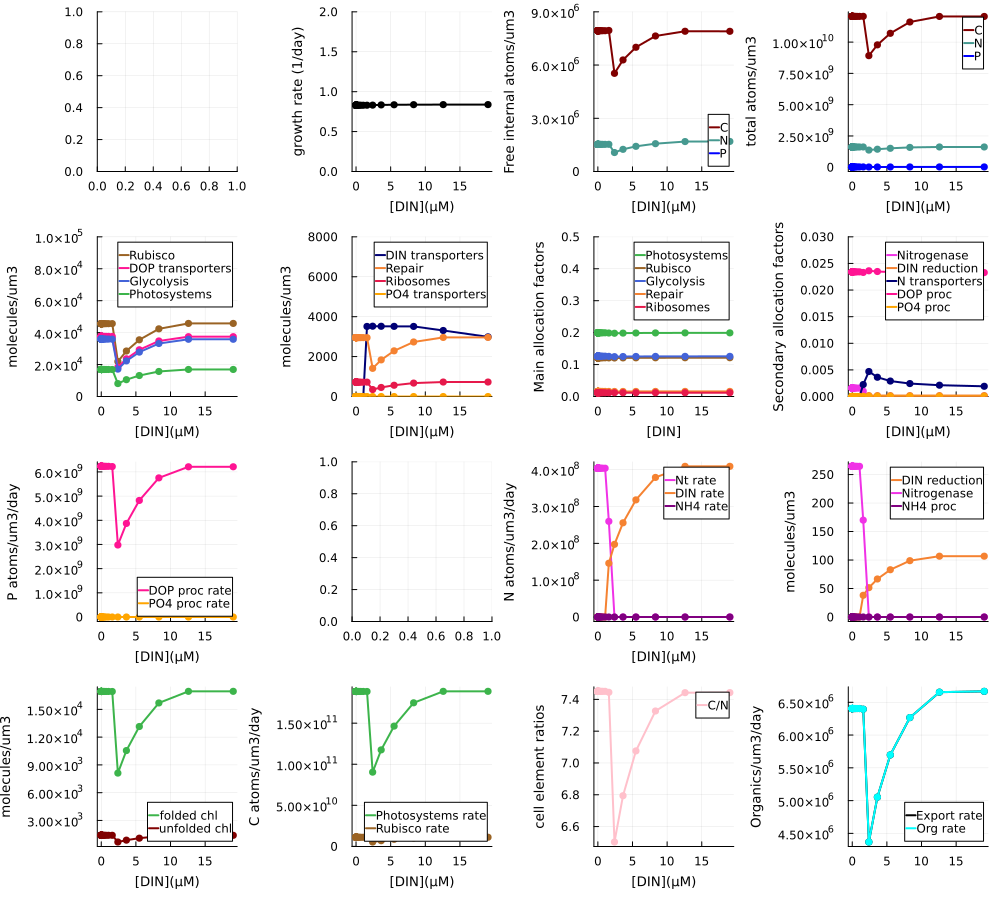

In [27]:
#Max daily growth rate is (approximately 0.27 d-1 at a reference temperature of
#20C under current CO2 conditions according to the results of Hutchins et al. 2007
using Plots

gr()

# Convert temperature to degree Celsius
change_T = change_T .- 273.0

using Printf
if env == "Temperature (C°)"
    variable = change_T
    a = 1:length(change_T)
elseif env == "[DIN]"
    variable = change_DIN
    b = 1:length(change_DIN)
elseif env == "Light"
    variable = change_I
    c = 1:length(change_I)
elseif env == "sfe"
    variable = change_sfe
    d = 1:length(change_sfe)
elseif env == "ffe"
    variable = change_ffe
    e = 1:length(change_ffe)
end


plot(layout = (4,4), guidefontsize = 9)

#plot!(variable, s_clm[a,b,c], color = "black", label = "", xlabel = env * "(μM)", ylabel = "Membrane lipids/um3", linewidth=2, subplot = 1)
#scatter!(variable, s_clm[a,b,c], color = "black", label = "", subplot = 1, markerstrokewidth=0)

plot!(variable, s_μ[a,b,c]*60*24, color = "black", label = "", linewidth=2, subplot = 2, legend=:bottomright)
scatter!(variable, s_μ[a,b,c]*60*24, color = "black", label = "", xlabel = env * "(μM)", ylabel = "growth rate (1/day)", ylims= (0.0, 2), subplot = 2, markerstrokewidth=0)
#plot!(variable,  s_ηaan[a,b,c]*60*24,  color = "#3cb44b", label = "ηaan", linewidth=2, subplot = 2)
#scatter!(variable,  s_ηaan[a,b,c]*60*24, color = "#3cb44b", label = "", subplot = 2, markerstrokewidth=0)

plot!(variable, s_cic[a,b,c], color = "#800000", label = "C", linewidth=2, subplot = 3)
scatter!(variable, s_cic[a,b,c], color = "#800000", label = "", markerstrokewidth=0, subplot = 3)
plot!(variable, s_cin[a,b,c], color = "#469990", label = "N", xlabel = env * "(μM)", ylabel = "Free internal atoms/um3", linewidth=2, ylims= (0.0, 9e6), subplot = 3)
scatter!(variable, s_cin[a,b,c], color = "#469990", label = "", markerstrokewidth=0, subplot = 3)
# plot!(variable, s_cife[a,b,c], color = "black", label = "Fe", linewidth=2, subplot = 3)
# scatter!(variable, s_cife[a,b,c], color = "black", label = "", markerstrokewidth=0, subplot = 3)
plot!(variable, s_cip[a,b,c], color = "blue", label = "P", linewidth=2, subplot = 3)
scatter!(variable, s_cip[a,b,c], color = "blue", label = "", markerstrokewidth=0, subplot = 3)

plot!(variable, s_Qc[a,b,c], color = "#800000",  label = "C", xlabel = env * "(μM)", ylabel = "total atoms/um3", linewidth=2, subplot = 4)
scatter!(variable, s_Qc[a,b,c], color = "#800000", label = "", subplot = 4, markerstrokewidth=0, legend=:topright)
plot!(variable, s_Qn[a,b,c], color = "#469990",  label = "N", xlabel = env * "(μM)", linewidth=2, subplot = 4)
scatter!(variable, s_Qn[a,b,c], color = "#469990", label = "", subplot = 4, markerstrokewidth=0, legend=:topright)
# plot!(variable, s_Qf[a,b,c], color = "black",  label = "Fe", xlabel = env * "(μM)", linewidth=2, subplot = 4)
# scatter!(variable, s_Qf[a,b,c], color = "black", label = "", subplot = 4, markerstrokewidth=0, legend=:topright)
plot!(variable, s_Qp[a,b,c], color = "blue",  label = "P", xlabel = env * "(μM)", linewidth=2, subplot = 4)
scatter!(variable, s_Qp[a,b,c], color = "blue", label = "", subplot = 4, markerstrokewidth=0, legend=:topright)


plot!(variable, s_pru[a,b,c], color = "#9A6324",  label = "Rubisco", linewidth=2, subplot = 5, ylims = (0.0, 1e5))
scatter!(variable,  s_pru[a,b,c], color = "#9A6324", label = "", markerstrokewidth=0, subplot = 5)
plot!(variable, s_pdop[a,b,c], color = "deeppink", label = "DOP transporters", xlabel = env * "(μM)", linewidth=2, subplot = 5)
scatter!(variable, s_pdop[a,b,c], color = "deeppink", label = "", subplot = 5, markerstrokewidth=0)
plot!(variable, s_pgl[a,b,c], color = "#4363d8",  label = "Glycolysis", linewidth=2, subplot = 5)
scatter!(variable,  s_pgl[a,b,c], color = "#4363d8", label = "", markerstrokewidth=0, subplot = 5)
plot!(variable, (s_pp[a,b,c]), color = "#3cb44b",  label = "Photosystems", xlabel = env * "(μM)", ylabel = "molecules/um3", linewidth=2, subplot = 5)
scatter!(variable,  (s_pp[a,b,c]), color = "#3cb44b", label = "", subplot = 5, markerstrokewidth=0, legend=:topright)

plot!(variable, s_ptrn[a,b,c], color = "#000075", label = "DIN transporters", xlabel = env * "(μM)", linewidth=2, subplot = 6, ylims = (0.0, 8000))
scatter!(variable, s_ptrn[a,b,c], color = "#000075", label = "", subplot = 6, markerstrokewidth=0)
plot!(variable, s_pre[a,b,c], color = "#f58231",  label = "Repair", linewidth=2, subplot = 6, ylabel = "molecules/um3")
scatter!(variable,  s_pre[a,b,c], color = "#f58231", label = "", markerstrokewidth=0, subplot = 6)
plot!(variable, s_pri[a,b,c], color = "#e6194B",  label = "Ribosomes", linewidth=2, subplot = 6)
scatter!(variable,  s_pri[a,b,c], color = "#e6194B", label = "", markerstrokewidth=0,subplot = 6)
plot!(variable, s_ptrpo4[a,b,c], color = "orange", label = "PO4 transporters", xlabel = env * "(μM)", linewidth=2, subplot = 6)
scatter!(variable, s_ptrpo4[a,b,c], color = "orange", label = "", subplot = 6, markerstrokewidth=0)

plot!(variable,  s_ϕp[a,b,c],  color = "#3cb44b", label = "Photosystems", xlabel = env * "(μM)", ylabel = "Main allocation factors", ylims = (0.0, 0.5),linewidth=2, subplot = 7)
scatter!(variable,  s_ϕp[a,b,c], color = "#3cb44b", label = "", xlabel = env, markerstrokewidth=0, subplot = 7)
plot!(variable, s_ϕru[a,b,c], color = "#9A6324",   label = "Rubisco", subplot = 7, linewidth=2, legend=:topright)
scatter!(variable,  s_ϕru[a,b,c], color = "#9A6324", label = "", markerstrokewidth=0, subplot = 7)
plot!(variable, s_ϕgl[a,b,c], color = "#4363d8",   label = "Glycolysis", subplot = 7, linewidth=2)
scatter!(variable,  s_ϕgl[a,b,c], color = "#4363d8", label = "", markerstrokewidth=0, subplot = 7)
plot!(variable, s_ϕre[a,b,c], color = "#f58231",   label = "Repair", linewidth=2, subplot = 7)
scatter!(variable,  s_ϕre[a,b,c], color = "#f58231", label = "", markerstrokewidth=0, subplot = 7)
plot!(variable, s_ϕri[a,b,c], color = "#e6194B",  label = "Ribosomes", linewidth=2, subplot = 7)
scatter!(variable,  s_ϕri[a,b,c], color = "#e6194B", label = "", markerstrokewidth=0, subplot = 7)

plot!(variable,  s_ϕnt[a,b,c],  color = "#f032e6", xlabel = env * "(μM)", label = "Nitrogenase", linewidth=2, subplot = 8, ylims = (0.0, 0.03))
scatter!(variable,  s_ϕnt[a,b,c], color = "#f032e6", label = "", ylabel = "Secondary allocation factors", markerstrokewidth=0, subplot = 8)
plot!(variable,  s_ϕdin[a,b,c],  color = "#f58231", label = "DIN reduction", linewidth=2, subplot = 8)
scatter!(variable,  s_ϕdin[a,b,c], color = "#f58231", label = "", markerstrokewidth=0, subplot = 8)
plot!(variable,  s_ϕtrn[a,b,c],  color = "#000075", label = "N transporters", linewidth=2, subplot = 8)
scatter!(variable,  s_ϕtrn[a,b,c], color = "#000075", label = "", markerstrokewidth=0, subplot = 8)
#plot!(variable,  s_ϕnh4[a,b,c],  color = "purple", label = "NH4 proc", linewidth=2, subplot = 8)
#scatter!(variable,  s_ϕnh4[a,b,c], color = "purple", label = "", markerstrokewidth=0, subplot = 8)
#plot!(variable,  s_ϕsFe[a,b,c],  color = "#000075", xlabel = env * "(μM)", label = "Sid bound-Fe", linewidth=2, subplot = 8)
#scatter!(variable,  s_ϕsFe[a,b,c], color = "#000075", label = "", ylabel = "Fe and P-related allocation factors", markerstrokewidth=0, subplot = 8)
#plot!(variable,  s_ϕfFe[a,b,c],  color = "#e6194B", label = "other Fe", linewidth=2, subplot = 8)
#scatter!(variable,  s_ϕfFe[a,b,c], color = "#e6194B", label = "", markerstrokewidth=0, subplot = 8)
plot!(variable,  s_ϕdop[a,b,c],  color = "deeppink", label = "DOP proc", linewidth=2, subplot = 8)
scatter!(variable,  s_ϕdop[a,b,c], color = "deeppink", label = "", markerstrokewidth=0, subplot = 8)
plot!(variable,  s_ϕtrpo4[a,b,c],  color = "orange", label = "PO4 proc", linewidth=2, subplot = 8)
scatter!(variable,  s_ϕtrpo4[a,b,c], color = "orange", label = "", markerstrokewidth=0, subplot = 8)

plot!(variable,  s_vtrdop[a,b,c]*60*24,  color = "deeppink", label = "DOP proc rate", xlabel = env * "(μM)", ylabel = "P atoms/um3/day", linewidth=2, subplot = 9)
scatter!(variable,  s_vtrdop[a,b,c]*60*24, color = "deeppink", label = "", markerstrokewidth=0, subplot = 9, legend=:bottomright)
plot!(variable,  s_vtrpo4[a,b,c]*60*24,  color = "orange", label = "PO4 proc rate", linewidth=2, subplot = 9)
scatter!(variable,  s_vtrpo4[a,b,c]*60*24, color = "orange", label = "", markerstrokewidth=0, subplot = 9)

# plot!(variable,  s_vsFe[a,b,c]*60*24,  color = "#000075", label = "Sb Fe proc rate", xlabel = env * "(μM)", ylabel = "Fe atoms/um3/day", linewidth=2, subplot = 10)
# scatter!(variable,  s_vsFe[a,b,c]*60*24, color = "#000075", label = "", markerstrokewidth=0, subplot = 10, legend=:bottomright)
# plot!(variable,  s_vtrfFe[a,b,c]*60*24,  color = "#e6194B", label = "other Fe proc rate", linewidth=2, subplot = 10)
# scatter!(variable,  s_vtrfFe[a,b,c]*60*24, color = "#e6194B", label = "", markerstrokewidth=0, subplot = 10)

plot!(variable,  s_vnt[a,b,c]*60*24,  color = "#f032e6", label = "Nt rate", xlabel = env * "(μM)", legend=:topright, ylabel = "N atoms/um3/day", linewidth=2, subplot = 11)
scatter!(variable,  s_vnt[a,b,c]*60*24, color = "#f032e6", label = "", markerstrokewidth=0, subplot = 11)
plot!(variable,  s_vtrn[a,b,c]*60*24,  color = "#f58231", label = "DIN rate", linewidth=2, subplot = 11)
scatter!(variable,  s_vtrn[a,b,c]*60*24, color = "#f58231", label = "", markerstrokewidth=0, subplot = 11)
plot!(variable,  s_vnh4[a,b,c]*60*24,  color = "purple", label = "NH4 rate", linewidth=2, subplot = 11)
scatter!(variable,  s_vnh4[a,b,c]*60*24, color = "purple", label = "", markerstrokewidth=0, subplot = 11)


plot!(variable, s_pdin[a,b,c], color = "#f58231", label = "DIN reduction", linewidth=2, subplot = 12, ylabel = "molecules/um3",)
scatter!(variable, s_pdin[a,b,c], color = "#f58231", label = "", markerstrokewidth=0, subplot = 12)
plot!(variable, s_pnt[a,b,c], color = "#f032e6", label = "Nitrogenase", linewidth=2, subplot = 12)
scatter!(variable, s_pnt[a,b,c], color = "#f032e6", label = "", markerstrokewidth=0, subplot = 12)
plot!(variable, s_pnh4[a,b,c], color = "purple", label = "NH4 proc", linewidth=2, subplot = 12)
scatter!(variable, s_pnh4[a,b,c], color = "purple", label = "", markerstrokewidth=0, subplot = 12)
# plot!(variable, s_psFe[a,b,c], color = "#000075", label = "Sb Fe proteins", xlabel = env * "(μM)", ylabel = "molecules/um3", linewidth=2, subplot = 12)
# scatter!(variable, s_psFe[a,b,c], color = "#000075", label = "", subplot = 12, markerstrokewidth=0, legend=:topright, ylims = (0.0, 500))
# plot!(variable, s_pfFe[a,b,c], color = "#e6194B", label = "other Fe proteins", linewidth=2, subplot = 12)
# scatter!(variable, s_pfFe[a,b,c], color = "#e6194B", label = "", markerstrokewidth=0, subplot = 12)

plot!(variable, (s_pp[a,b,c]), color = "#3cb44b",  label = "folded chl", xlabel = env * "(μM)", linewidth=2, ylabel = "molecules/um3", subplot = 13)
scatter!(variable,  s_pp[a,b,c], color = "#3cb44b", label = "", subplot = 13, markerstrokewidth=0, legend=:bottomright)
plot!(variable, (s_pdp[a,b,c]), color = "#800000",  label = "unfolded chl", linewidth=2, subplot = 13)
scatter!(variable,  s_pdp[a,b,c], color = "#800000", label = "", markerstrokewidth=0, subplot = 13)

plot!(variable,  s_vp[a,b,c]*60*24,  color = "#3cb44b", label = "Photosystems rate", linewidth=2, subplot = 14)
scatter!(variable,  e_p*s_vp[a,b,c]*60*24, color = "#3cb44b", label = "", subplot = 14, markerstrokewidth=0)
plot!(variable,  s_vru[a,b,c]*60*24,  color = "#9A6324", label = "Rubisco rate", xlabel = env * "(μM)", ylabel = "C atoms/um3/day", 
linewidth=2, subplot = 14)
scatter!(variable,  s_vru[a,b,c]*60*24, color = "#9A6324", label = "", markerstrokewidth=0, subplot = 14, legend=:bottomright)


#plot!(variable, transpose(1/s_Qcell[a,b,c]), color = "pink",  label = "total C/N", xlabel = env * "(μM)", ylabel = "cell C:N ratio", ylims = (0.005,10), linewidth=2, subplot = 15)
#scatter!(variable, transpose(1/s_Qcell[a,b,c]), color = "pink", label = "", subplot = 15, markerstrokewidth=0, legend=:topright)
plot!(variable, s_Qcell[a,b,c], color = "pink",  label = "C/N", xlabel = env * "(μM)", ylabel = "cell element ratios", linewidth=2, subplot = 15)
scatter!(variable, s_Qcell[a,b,c], color = "pink", label = "", subplot = 15, markerstrokewidth=0, legend=:topright)
#plot!(variable, s_Fcell[a,b,c], color = "orange",  label = "C/Fe", xlabel = env * "(μM)", linewidth=2, subplot = 15)
#scatter!(variable, s_Fcell[a,b,c], color = "orange", label = "", subplot = 15, markerstrokewidth=0, legend=:topright)

#plot!(variable, vec(permutedims(s_cic./s_cin, [2,1,3,4,5])), color = "black",  label = "free C/N", xlabel = env * "(μM)", linewidth=2, subplot = 15)
#scatter!(variable, vec(permutedims(s_cic./s_cin, [2,1,3,4,5])), color = "black", label = "", subplot = 15, markerstrokewidth=0, legend=:topright)


# plot!(variable, s_cgu[a,b,c], color = "purple", label = "starch", xlabel = env * "(μM)", ylabel ="C atoms/um3/day", linewidth=2, subplot = 15)
# scatter!(variable, s_cgu[a,b,c], color = "purple", label = "", markerstrokewidth=0, subplot = 15)
# #plot!(variable, s_cli[a,b,c], color = "deeppink", label = "TAGs_resp", subplot = 15)
# #scatter!(variable, s_cli[a,b,c], color = "deeppink", label = "", subplot = 15)
# plot!(variable, s_ctag[a,b,c], color = "pink", label = "TAGs_ROS", linewidth=2, subplot = 15)
# scatter!(variable, s_ctag[a,b,c], color = "pink", label = "", markerstrokewidth=0, subplot = 15)


plot!(variable,  s_vexp[a,b,c]*60*24,  color = "black", label = "Export rate", linewidth=2, subplot = 16, ylabel = "Organics/um3/day")
scatter!(variable,  s_vexp[a,b,c]*60*24, color = "black", label = "", markerstrokewidth=0, subplot = 16)
plot!(variable,  s_vorg[a,b,c]*60*24,  color = "cyan", label = "Org rate", linewidth=2, subplot = 16)
scatter!(variable,  s_vorg[a,b,c]*60*24, color = "cyan", label = "", markerstrokewidth=0, subplot = 16)

nATP = s_vri[a,b,c]*e_ri + s_vtrn[a,b,c]*e_trn + s_vnt[a,b,c]*e_nt
#cue = 1 .- s_vnaq[a,b,c]./s_vru[a,b,c]


#plot!(variable, cue, color = "black", label = "CUE", xlabel = env * "(μm)", ylabel = "carbon use efficiency", subplot = 15)
#scatter!(variable, cue, color = "black", label = "", ylims = (0,1), subplot = 15)



plot!(size=(1000,900))
#savefig("tricho_P_expP.pdf")




In [172]:
if env == "Temperature (C°)"
    savefig("./model_output.pdf")
elseif env == "[DIN]"
    savefig("./din.pdf")
elseif env == "Light"
    savefig("./light.pdf")
end

"/Users/dosorior/Library/CloudStorage/OneDrive-UniversityofSouthernCalifornia/git/din.pdf"